In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.nn.utils.parametrizations import weight_norm
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
from tqdm import tqdm
import sys, os
sys.path.append(os.path.abspath("../../lib"))
import util
import importlib
importlib.reload(util)

<module 'util' from 'C:\\Users\\amand\\Documents\\Research\\Project_LIDI\\VAE_Tutorials\\lib\\util.py'>

# Introduction

Let's do an ablation study on three elements of the LVAE architecture.
1. **Type of normalization**. We'll consider no normalization of any kind, batch normalization (applied to data), and weight normalization (applied to network weights). We also look at the combination of batch and weight normalization.
2. **Number of hierarchical levels**. Similar to the original LVAE paper, we'll look at how the number of hierarchical levels (from 2 to 5) affects training loss and latent space geometry. The geometry is found by a 2-dimensional PCA projection of latents in each hierarchical level.
3. **Number of hidden layers**. Does increased depth and capacity per MLP help find a more structured latent space?

All results are based on the MNIST dataset.

# Setup

### MLP network
Provides a flexible definition for different types of ablations.

In [2]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden, **kwargs):
        super().__init__()
        
        slope = 0.01
        num_layers = kwargs.get('num_layers', 2)  # number of (linear, activation) blocks before output
        norm_type = kwargs.get('norm_type')

        hidden_dims = [in_dim] + num_layers * [hidden]

        # Define middle layers
        layer_lst = []
        for n in range(num_layers):
            # Linear layer (+ normalization)
            if norm_type == 'none':
                layer_lst.append(nn.Linear(hidden_dims[n], hidden_dims[n + 1]))
            elif norm_type == 'weight':
                layer_lst.append(weight_norm(nn.Linear(hidden_dims[n], hidden_dims[n + 1])))
            elif norm_type == 'batch':
                layer_lst.append(nn.Linear(hidden_dims[n], hidden_dims[n + 1]))
                layer_lst.append(nn.BatchNorm1d(hidden_dims[n+1]))
            elif norm_type == 'batch_weight':
                layer_lst.append(weight_norm(nn.Linear(hidden_dims[n], hidden_dims[n + 1])))
                layer_lst.append(nn.BatchNorm1d(hidden_dims[n + 1]))

            # Activation
            layer_lst.append(nn.LeakyReLU(slope))

        self.layers = nn.Sequential(*layer_lst)

        # Define output layers
        self.mu = nn.Linear(hidden_dims[-1], out_dim)
        self.log_var = nn.Linear(hidden_dims[-1], out_dim)

    def forward(self, x, return_intermed=False):
        out = self.layers(x)

        output = []
        if return_intermed:
            output.append(out)
        output.append(self.mu(out))
        output.append(self.log_var(out))
        return output

### LVAE model

In [3]:
class LVAE(nn.Module):
    def __init__(self, kx, **kwargs):
        super().__init__()

        self.kx = kx

        # Default values are for original iVAE
        self.pz = kwargs.get('pz')
        self.num_hier = len(self.pz)  # number of hierarchical layers, must be at least 2
        self.hidden_dim = kwargs.get('hidden_dim')
        self.n_warmup = kwargs.get('n_warmup')  # number of epochs for KL loss annealing

        self.encoders = nn.ParameterList()
        self.decoders = nn.ParameterList()

        self.encoders.append(MLP(self.kx, self.pz[0], self.hidden_dim[0], **kwargs))
        for i in range(1, self.num_hier):
            mlp_enc = MLP(self.hidden_dim[i - 1], self.pz[i], self.hidden_dim[i], **kwargs)
            self.encoders.append(mlp_enc)
            mlp_dec = MLP(self.pz[self.num_hier-i], self.pz[self.num_hier-i-1], self.hidden_dim[-i], **kwargs)
            self.decoders.append(mlp_dec)
        self.decoders.append(MLP(self.pz[0], self.kx, self.hidden_dim[0], **kwargs))

    def forward(self, x):
        # hat = deterministic encoder layer, qs = stochastic encoder layer, ps = decoder layer
        mu_hats, mu_qs, mu_ps = [], [], []
        logvar_hats, logvar_qs, logvar_ps = [], [], []

        # === Encoder pass
        val = x
        for i in range(self.num_hier):
            val, mu_i_hat, logvar_i_hat = self.encoders[i](val, return_intermed=True)
            mu_hats.append(mu_i_hat)
            logvar_hats.append(logvar_i_hat)

        # === Reparameterization (last layer only)
        self.z = []
        z_val = util.sample(mu_hats[-1], logvar_hats[-1])
        self.z.append(z_val)

        # === Decoder pass
        # Add q(z_L|x)
        mu_qs.append(mu_hats[-1])
        logvar_qs.append(logvar_hats[-1])
        # Add prior p(z_L) ~ N(0, I)
        mu_ps.append(torch.zeros_like(z_val))
        logvar_ps.append(torch.zeros_like(z_val))

        for i in range(self.num_hier):
            # Get p(z_i|z_i+1) or p(x|z_1)
            mu_p, logvar_p = self.decoders[i](z_val)
            mu_ps.append(mu_p)
            logvar_ps.append(logvar_p)

            if i < self.num_hier-1:
                # Construct compound distribution
                idx = self.num_hier - i - 2  # iterate backwards on (mu_hat, logvar_hat), exclude first set outside loop
                mu_q, logvar_q = util.compound_normal(mu_hats[idx], logvar_hats[idx], mu_p, logvar_p)
                mu_qs.append(mu_q)
                logvar_qs.append(logvar_q)
                # Sample
                z_val = util.sample(mu_q, logvar_q)
                self.z.append(z_val)

        return mu_hats, logvar_hats, mu_qs, logvar_qs, mu_ps, logvar_ps

    def loss(self, x, params, beta=1):
        mu_hats, logvar_hats, mu_qs, logvar_qs, mu_ps, logvar_ps = params

        recon = -1 * util.normal_ll(x, mu_ps[-1], logvar_ps[-1])
        kl_div = 0
        kl_per_hier = []
        for i in range(self.num_hier):
            kl = util.kl_normal(mu_qs[i], logvar_qs[i], mu_ps[i], logvar_ps[i])
            kl_per_hier.append(kl.mean())
            kl_div += kl
        return recon.mean(), beta * kl_div.mean(), kl_per_hier

    def anneal(self, iteration):
        if self.n_warmup <= 0:
            return 1
        beta = np.min([iteration / self.n_warmup, 1])
        return beta

    def get_z_samples(self):
        return self.z

### Prepare for training

In [4]:
# Load CPU or GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CUDA


In [5]:
# Training & model settings
cfg = {
    'rng': 1,
    'batch_size': 256,
    'epochs': 20,
    'lr': 0.0001,
    'n_warmup': 2,
    'data_src': 'MNIST',
    'pz': [64, 32, 16],
    'hidden_dim': [256, 128, 64]
}

# Set random seed
torch.manual_seed(cfg['rng'])
np.random.seed(cfg['rng'])

In [6]:
# Load dataset
data, kx = util.get_dataset(**cfg)
generator = torch.Generator().manual_seed(cfg['rng'])
train_data, valid_data, test_data = random_split(data, [0.8, 0.1, 0.1], generator=generator)
train_loader = DataLoader(train_data, cfg['batch_size'], shuffle=True)
test_loader = DataLoader(test_data, batch_size=len(test_data))

# Investigation 1: Effect of normalization

### Training

In [7]:
norm_types = ['batch', 'weight', 'batch_weight', 'none']

recon_arr1, kl_arr1, kl_hier_arr1 = [], [], []
metrics_arr1 = []

for norm in norm_types:
    print("Norm type: " + norm)
    cfg['norm_type'] = norm

    model = LVAE(kx, **cfg).to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=cfg['lr'])
    util.get_num_parameters(model)
    
    recon, kl, kl_hier, metrics = util.train_lvae(model, optimizer, train_loader, device, **cfg)

    # Save loss
    recon_arr1.append(recon)
    kl_arr1.append(kl)
    kl_hier_arr1.append(kl_hier)
    metrics_arr1.append(metrics)

Norm type: batch
Number of parameters: 907456


100%|██████████| 20/20 [01:22<00:00,  4.10s/it]


Norm type: weight
Number of parameters: 905664


100%|██████████| 20/20 [01:15<00:00,  3.76s/it]


Norm type: batch_weight
Number of parameters: 909248


100%|██████████| 20/20 [01:18<00:00,  3.94s/it]


Norm type: none
Number of parameters: 903872


100%|██████████| 20/20 [01:09<00:00,  3.48s/it]


### Plot overall training loss

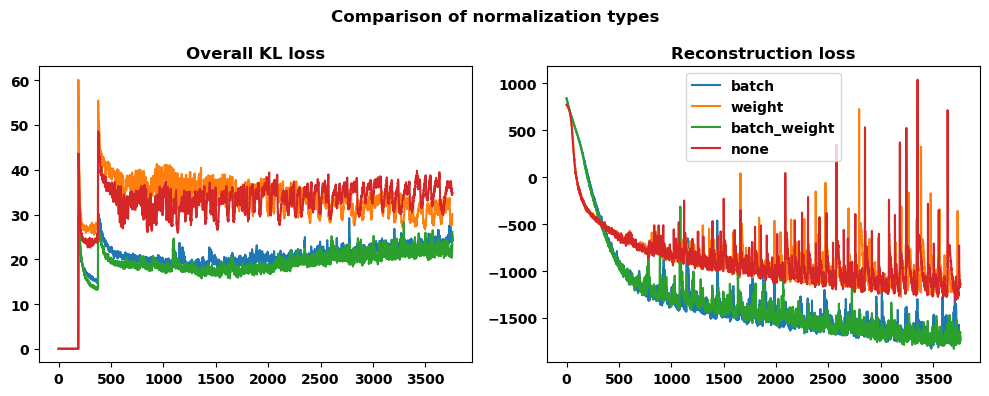

In [8]:
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=True, figsize=(10,4))

for i in range(len(recon_arr1)):
    axs[0].plot(kl_arr1[i], label=norm_types[i])
    axs[1].plot(recon_arr1[i], label=norm_types[i])
axs[0].set_title("Overall KL loss")
axs[1].set_title("Reconstruction loss")
plt.legend()
plt.suptitle("Comparison of normalization types")
plt.tight_layout()

### Plot KL loss per hierarchy

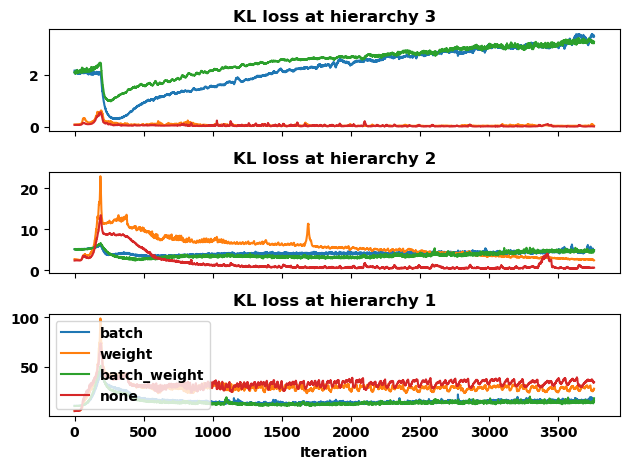

In [9]:
num_hier = kl_hier_arr1[0].shape[1]
fig, axs = plt.subplots(nrows=num_hier, ncols=1, sharex=True)

for i in range(num_hier):
    for j in range(len(kl_hier_arr1)):
        axs[i].plot(kl_hier_arr1[j][:, i], label=norm_types[j])
        axs[i].set_title("KL loss at hierarchy " + str(num_hier-i))
axs[i].set_xlabel("Iteration")
plt.legend()
plt.tight_layout()

### Plot mutual information

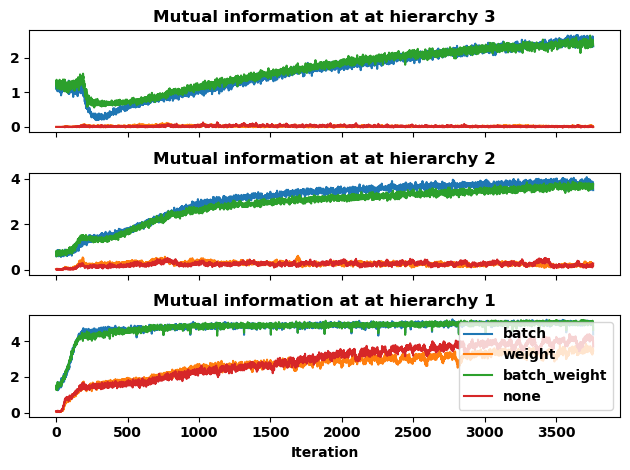

In [10]:
fig, axs = plt.subplots(nrows=num_hier, ncols=1, sharex=True)

for i in range(num_hier):
    for j in range(len(kl_hier_arr1)):
        ami_ij = np.array(metrics_arr1[j]['ami'])
        axs[i].plot(ami_ij[:, i], label=norm_types[j])
        axs[i].set_title("Mutual information at at hierarchy " + str(num_hier-i))
axs[i].set_xlabel("Iteration")
plt.legend()
plt.tight_layout()

# Investigation 2: Number of hierarchical levels

### Training

In [11]:
# Reset
cfg['norm_type'] = 'batch'

pz_dims = [64, 32, 16, 8, 4]
hidden_dim = [256, 128, 64, 32, 16]

recon_arr2, kl_arr2, kl_hier_arr2 = [], [], []
metrics_arr2 = []
models_2 = []

for dim in range(2, len(pz_dims)+1):
    print("Num hierarchies: " + str(dim))
    cfg['pz'] = pz_dims[:dim]
    cfg['hidden_dim'] = hidden_dim[:dim]

    model = LVAE(kx, **cfg).to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=cfg['lr'])
    util.get_num_parameters(model)
    
    recon, kl, kl_hier, metrics = util.train_lvae(model, optimizer, train_loader, device, **cfg)

    # Save loss
    recon_arr2.append(recon)
    kl_arr2.append(kl)
    kl_hier_arr2.append(kl_hier)
    metrics_arr2.append(metrics)
    models_2.append(model)

Num hierarchies: 2
Number of parameters: 883040


100%|██████████| 20/20 [01:08<00:00,  3.44s/it]


Num hierarchies: 3
Number of parameters: 907456


100%|██████████| 20/20 [01:17<00:00,  3.85s/it]


Num hierarchies: 4
Number of parameters: 913776


100%|██████████| 20/20 [01:27<00:00,  4.37s/it]


Num hierarchies: 5
Number of parameters: 915464


100%|██████████| 20/20 [01:32<00:00,  4.61s/it]


### Plot overall training loss

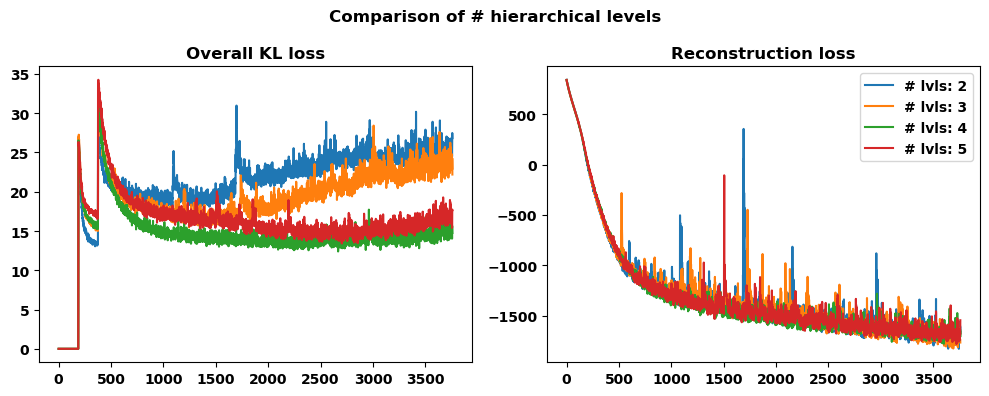

In [12]:
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=True, figsize=(10,4))

for i in range(len(recon_arr2)):
    axs[0].plot(kl_arr2[i], label="# lvls: " + str(i+2))
    axs[1].plot(recon_arr2[i], label="# lvls: " + str(i+2))
axs[0].set_title("Overall KL loss")
axs[1].set_title("Reconstruction loss")
plt.legend()
plt.suptitle("Comparison of # hierarchical levels")
plt.tight_layout()

### Plot KL loss per hierarchy

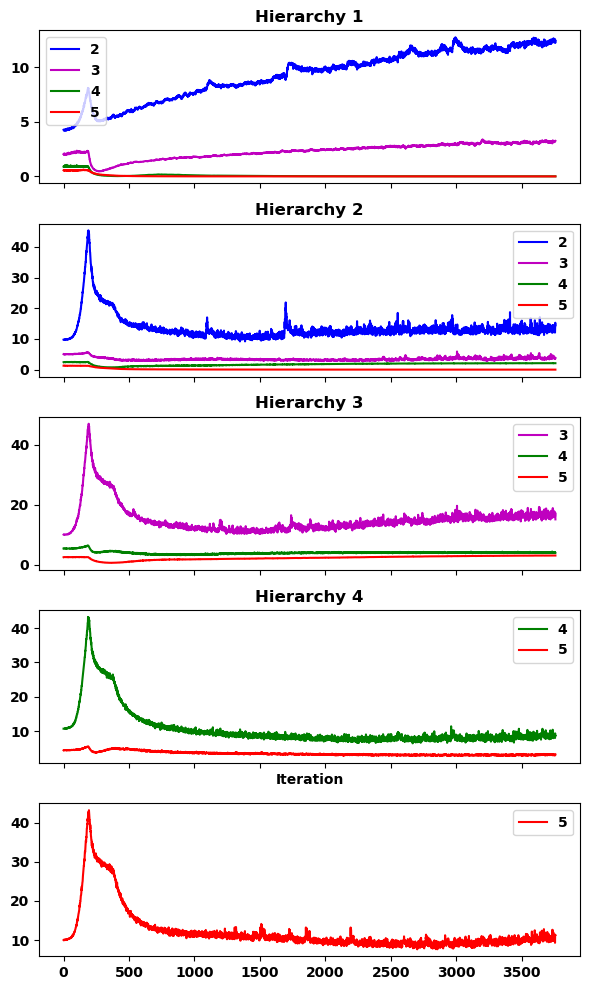

In [13]:
max_hierarchy = len(pz_dims)
fig, axs = plt.subplots(nrows=max_hierarchy, ncols=1, sharex=True, figsize=(6, 10))

num_compare = len(kl_hier_arr2)
colors = ['b', 'm', 'g', 'r']

for i in range(num_compare):
    kl_i = kl_hier_arr2[i]
    dim_i = kl_i.shape[1]
    for j in range(dim_i):
        axs[j].plot(kl_i[:, j], label=str(dim_i), c=colors[i])
        axs[j].legend()
    axs[i].set_title("Hierarchy " + str(i+1))
axs[i].set_xlabel("Iteration")
plt.legend()
plt.tight_layout()

The uppermost layer of a network of any number of layers has the most structured latent space (e.g., largest KL loss). However, for persistent and deep structure, models with 2 and 3 levels seem to manage this empirical trade-off best for MNIST.

### Plot mutual information

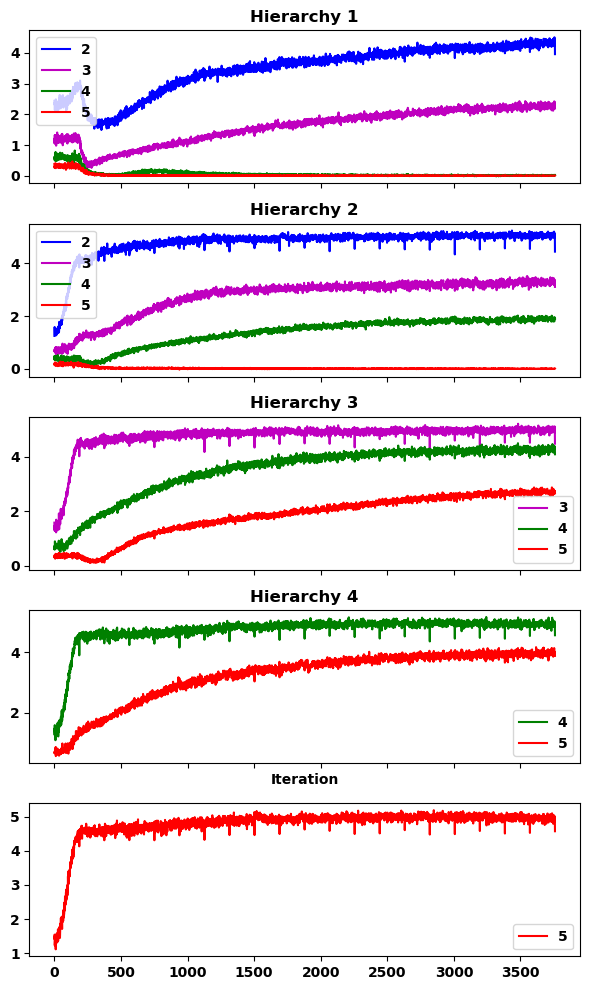

In [14]:
max_hierarchy = len(pz_dims)
fig, axs = plt.subplots(nrows=max_hierarchy, ncols=1, sharex=True, figsize=(6, 10))

num_compare = len(kl_hier_arr2)
colors = ['b', 'm', 'g', 'r']

for i in range(num_compare):
    kl_i = kl_hier_arr2[i]
    dim_i = kl_i.shape[1]
    for j in range(dim_i):
        ami_j = np.array(metrics_arr2[i]['ami'])
        axs[j].plot(ami_j[:, j], label=str(dim_i), c=colors[i])
        axs[j].legend()
    axs[i].set_title("Hierarchy " + str(i+1))
axs[i].set_xlabel("Iteration")
plt.legend()
plt.tight_layout()

### Plot 2d PCA representation per hierarchy for each model of increasing depth

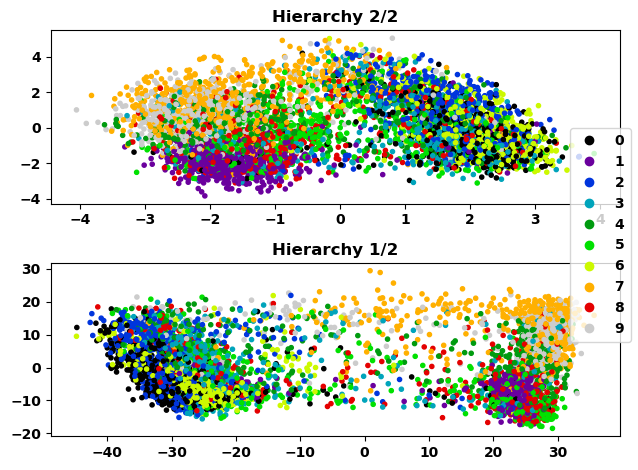

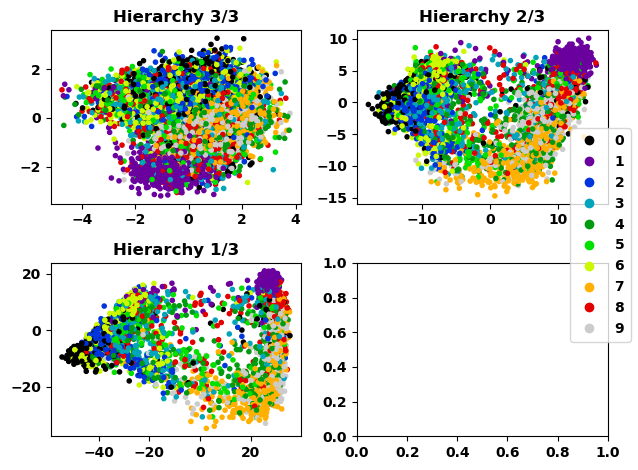

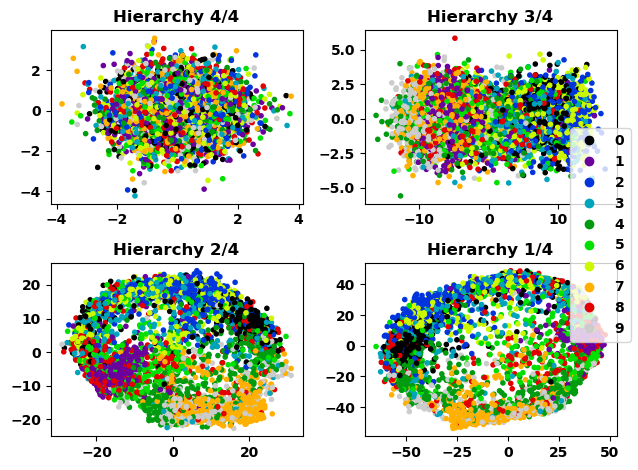

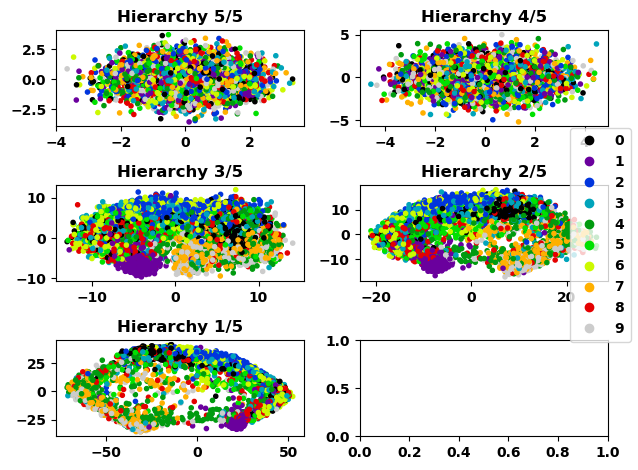

In [15]:
desired = models_2
for i, mdl in enumerate(models_2):
    mdl.eval()
    with torch.no_grad():
        for batch in test_loader:
            x, u = util.get_batch(batch, cfg['data_src'], device)
            output = mdl(x)
    
    zs = mdl.get_z_samples()
    titles = ["Hierarchy " + str(i+2-j) + "/" + str(i+2) for j in range(i+2)]
    u = u.detach().cpu()
    util.plot_multiple_pca(zs, lbls=u, title_lst=titles)

# Investigation 3: Number of hidden layers

### Training

In [16]:
# Reset
cfg['pz'] = [64, 32, 16]
cfg['hidden_dim'] = [265, 128, 64]

layer_dims = [1, 2, 3, 5]

recon_arr3, kl_arr3, kl_hier_arr3 = [], [], []
metrics_arr3 = []

for dim in layer_dims:
    print("# MLP hidden layers: " + str(dim))
    cfg['num_layers'] = dim

    model = LVAE(kx, **cfg).to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=cfg['lr'])
    util.get_num_parameters(model)

    recon, kl, kl_hier, metrics = util.train_lvae(model, optimizer, train_loader, device, **cfg)

    # Save loss
    recon_arr3.append(recon)
    kl_arr3.append(kl)
    kl_hier_arr3.append(kl_hier)
    metrics_arr3.append(metrics)

# MLP hidden layers: 1
Number of parameters: 756838


100%|██████████| 20/20 [01:08<00:00,  3.41s/it]


# MLP hidden layers: 2
Number of parameters: 940990


100%|██████████| 20/20 [01:10<00:00,  3.55s/it]


# MLP hidden layers: 3
Number of parameters: 1125142


100%|██████████| 20/20 [01:18<00:00,  3.93s/it]


# MLP hidden layers: 5
Number of parameters: 1493446


100%|██████████| 20/20 [01:23<00:00,  4.20s/it]


### Plot overall training loss

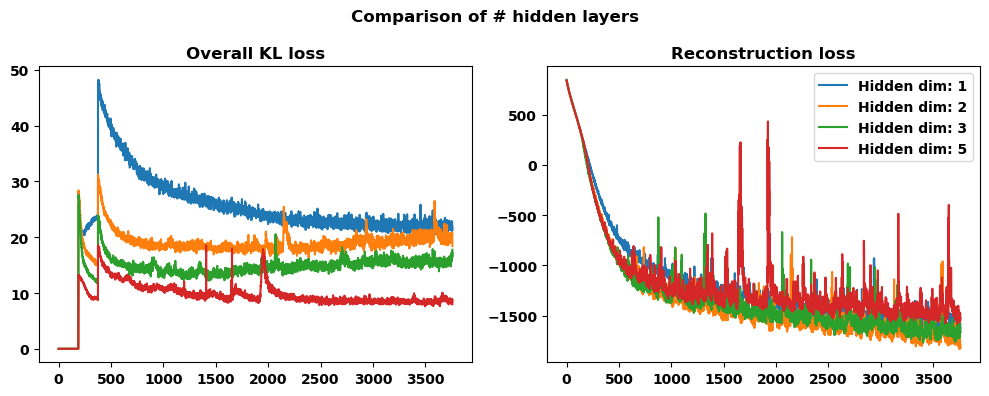

In [17]:
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=True, figsize=(10,4))

for i in range(len(recon_arr3)):
    axs[0].plot(kl_arr3[i], label="Hidden dim: " + str(layer_dims[i]))
    axs[1].plot(recon_arr3[i], label="Hidden dim: " + str(layer_dims[i]))
axs[0].set_title("Overall KL loss")
axs[1].set_title("Reconstruction loss")
plt.legend()
plt.suptitle("Comparison of # hidden layers")
plt.tight_layout()

### Plot mutual information

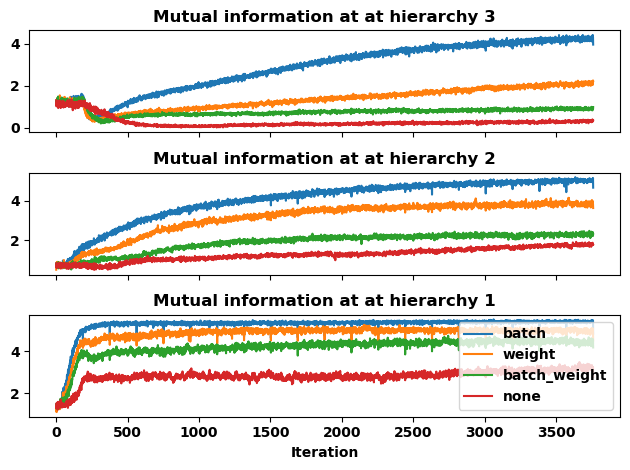

In [18]:
fig, axs = plt.subplots(nrows=num_hier, ncols=1, sharex=True)

for i in range(num_hier):
    for j in range(len(kl_hier_arr3)):
        ami_ij = np.array(metrics_arr3[j]['ami'])
        axs[i].plot(ami_ij[:, i], label=norm_types[j])
        axs[i].set_title("Mutual information at at hierarchy " + str(num_hier-i))
axs[i].set_xlabel("Iteration")
plt.legend()
plt.tight_layout()